# Sieci Neuronowe i algorytmy genetyczne - projekt 2026
Temat: Linear Klasyfikacja danych z biblioteką Keras (TensorFlow)

Wybrane zagadnienie: Linear Neural Networks for Regression

Autorzy:
Grzegorz Potocki, Tomasz Majchrzak

## Wprowadzenie

Niniejszy projekt został opracowany w celu realizacji klasyfikacji obrazów z datasetu `fashion_minst` zintegrowanego z biblioteką `keras`. Kluczowymi krokami niezbędnymi do poprawnego przeporowadzenia treningu sieci neuronoej (w tym wypadku zgodnie z wybranym zagadnieniem jest to liniowa sieć neuronowa) oraz oceny rezultatów jest odpowiednia analiza eksploracyjna EDA (ang. Exploratory Data Analysis) oraz etap preprocessingu danych.

Wybranym datasetem jest właśnie `fashion_minst`, który zawiera łącznie 70 000 obrazów różnych ubrań i akcesoriów przeznaczonych do przeprowadzenia klasyfikacji.

Do wczytania oraz eksploracyjnej analizy danych zostaną wykorzystane takie moduły jak `numpy`, `pandas`, `seaborn`, `matplotlib` oraz poźniej `pillow` w celu zapisania błędnych klasyfikacji do odpowiednich folderów. Głównymi narzędziami potrzebnymi do zbudowania, treningu oraz testowania sieci neuronowych będą moduły `tensorflow` oraz `keras`. 

Projekt skupia się na porównianiu wydajności ze względu na zmianę konkretnych parametrów liniowej sieci neuronowej oraz nieliniowej DNN (ang. Deep Neural Network) z warstwami ukrytmi.  

#TODO
DOPISAĆ POŹNIEJ JAKIE METRYKI PRZYJĘTO DO OCENY MODELI

## Konfiguracja środowiska

Pierwszym obowiązkowym krokiem w procesie budowania i ewaluacji sieci neuronowych jest poprawna konfiguracja środowiska, w którym będzie się pracować. W tym celu za pomocą modułu `os` zostały wyłączone potencjalne fałszywe komunikaty związane z błędami instalacji modułu `keras` oraz `tensorflow` na systemie linux. Ponad to zaimplementowano małą poprawkę do modułu `numpy` - wyświetlanie liczb zmiennoprzecinkowy z prezycją tylko do trzech liczb po przecinku oraz wyłączenie notacji naukowej dla małych liczb.

In [223]:
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image


np.set_printoptions(precision=3, suppress=True)

In [224]:
import tensorflow as tf
import keras
from keras import layers

W tym miejscu w ramach utrzymania przejrzystości kodu zostają wyświetlone użyte wersje modułów `tensorflow` oraz `keras`.

In [225]:
print(tf.__version__, keras.__version__)

2.21.0 3.14.1


Zgodnie z przyjętą konwecją podczas pracy z sieciami neuronowymi zostały również zdefiniowane wartości `set_seed` dla `tensorflow` oraz `seed` dla `numpy` w ramach powtarzalności wyników.

In [226]:
tf.random.set_seed(42)
np.random.seed(42)

## Eksploracyjna analiza danych (EDA)

Ze względu na to, że dataset jest już zintegorwany z modułem `keras` wystarczy tylko go załadować do odpowiednich zmiennych. Dane zawarte w tym module zostały w łatwy sposób można posortować na treningowe i testowe oraz nie wymagają żadnego potencjalnego pozbywania sie wartości `NaN` jak to mogłoby się przydarzyć w zewnętrznych datasetach.

In [227]:
# Ładowanie zbioru danych
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Definicje nazw klas
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Po załadowaniu danych warto sprawdzić jaki kształt mają teraz poszczególne zmienne.

In [228]:
# Kształty zbiorów treningowych
print("Zbiór treningowy - obrazy:", train_images.shape)
print("Zbiór treningowy - etykiety:", train_labels.shape)
print("Zbiór testowy - obrazy:", test_images.shape)
print("Zbiór testowy - etykiety:", test_labels.shape)

Zbiór treningowy - obrazy: (60000, 28, 28)
Zbiór treningowy - etykiety: (60000,)
Zbiór testowy - obrazy: (10000, 28, 28)
Zbiór testowy - etykiety: (10000,)


Pomimo faktu, że dane są prawie odrazu gotowe do pracy z sieciami neuronowymi to i tak trzeba je poddac normalizcji. Zanim jednak się do tego przejdzie, należy sprawdzić jaki typ oraz jakie sa oryginalne wartości, aby późniejsza normalizacjia była przeporwadzona w dobry sposób.

In [229]:
# Typ i zakres wartości przed normalizacją
print("Typ danych:", train_images.dtype)
print("Min wartość piksela:", train_images.min())
print("Max wartość piksela:", train_images.max())

Typ danych: uint8
Min wartość piksela: 0
Max wartość piksela: 255


Równie istotna sprawą oprócz samego zakresu wartości danych jest poznanie ich rozkładu. 

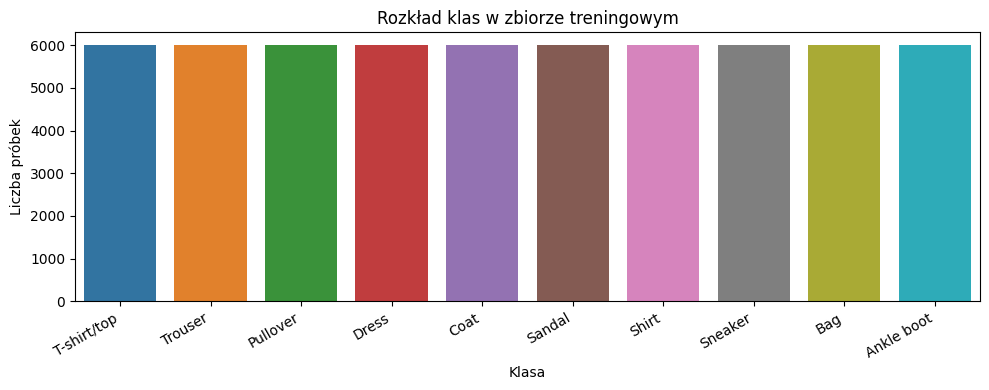

T-shirt/top: 6000 próbek
Trouser: 6000 próbek
Pullover: 6000 próbek
Dress: 6000 próbek
Coat: 6000 próbek
Sandal: 6000 próbek
Shirt: 6000 próbek
Sneaker: 6000 próbek
Bag: 6000 próbek
Ankle boot: 6000 próbek


In [230]:
unique, counts = np.unique(train_labels, return_counts=True)

class_labels = [class_names[i] for i in unique]

plt.figure(figsize=(10, 4))
sns.barplot(x=class_labels, y=counts, hue=class_labels, legend=False)
plt.title("Rozkład klas w zbiorze treningowym")
plt.xlabel("Klasa")
plt.ylabel("Liczba próbek")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

for name, count in zip(class_labels, counts):
    print(f"{name}: {count} próbek")

W tym miejscu juz wszystkie najważniejsze informacje z perspektwy budowania sieci neuronowych są juz wyświetlone, ale w ramach dodatkowej wizalizacji można wyświetlich po jednej przykładowej próbce z każdej klasy.

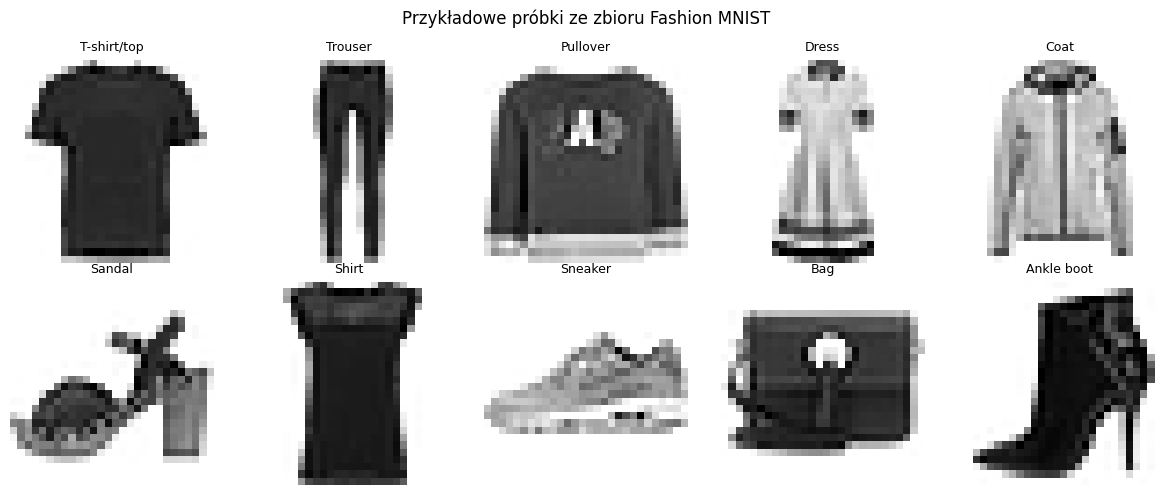

In [231]:
# Wizualna analiza zbioru danych
# Po jednej próbce z każdej z 10 klas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Przykładowe próbki ze zbioru Fashion MNIST")

for i, ax in enumerate(axes.flat):
    idx = np.random.choice(np.where(train_labels == i)[0])
    ax.imshow(train_images[idx], cmap="binary")
    ax.set_title(class_names[i], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Preprocessing i podział danych

Ze względu na to że, załadowny dataset w zasadzie jest gotowy do pracy jedyną rzeczą, która jest wymagana to znormalizowanie wartości pikseli.

In [232]:
# Normalizacja wartości pikseli
train_images_normalized = train_images / 255.0
test_images_normalized = test_images / 255.0

In [233]:
# Zakres wartości po normalizacji
print("Min wartość piksela:", train_images_normalized.min())
print("Max wartość piksela:", train_images_normalized.max())

Min wartość piksela: 0.0
Max wartość piksela: 1.0


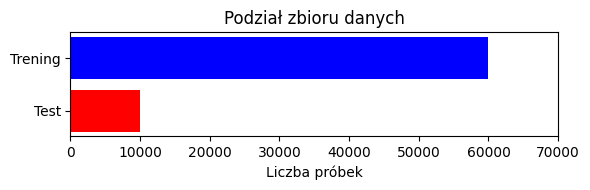

In [234]:
# Podział zbioru danych
plt.figure(figsize=(6, 2))
bars = plt.barh(["Test", "Trening"], [10000, 60000], color=["red", "blue"])
plt.xlabel("Liczba próbek")
plt.xlim(0, 70000)
plt.title("Podział zbioru danych")
plt.tight_layout()
plt.show()

## Budowa i trening modeli oraz ich ewaluacja

W tym miejscu zostaną przeprowadzone testy na liniowej sieci. W tym celu zostały zdefiniowane nastepujące funkcje:

- `build_linear_model()` - funkcja budująca prosty model liniowy za pomocą `keras_Sequential()`. Obraz jest spłaszczany do pojedynczego wektora, a warstwa wyjściowa przypisuje prawdopodobieństwo każdej z klas. 
- `plot_history()` - funkcja odpowiedzialna za wyświetlanie dwóch wykresów - pierwszy przedstawia jak zmienia się wartość wskaźnika accuracy względem postępująch epok, a drugi to charakterystyka wartości funkcji błędu względem epok
- `build_dnn_model()` - budowanie głębokiej sieci neuronowej z dwoma warstwami głebokimi, aktywowanymi za pomocą funkcji `relu`
- `run_experiment()` - funkcja pomocnicza, zbierająca w całość całą procedurę testową

In [235]:
all_results = []

In [ ]:
# Model liniowy: Flatten spłaszcza obraz 28x28 do wektora 784 pikseli
# Warstwa Dense(10, softmax) przypisuje prawdopodobieństwo każdej z 10 klas
def build_linear_model(lr):
    model = keras.Sequential([
        keras.Input(shape=(28,28)),
        layers.Flatten(),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
# Krzywe uczenia - dokładność na zbiorze treningowym
# i walidacyjnym w funkcji epoki
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title)

    # Krzywa accuracy
    axes[0].plot(history.history["accuracy"],     label="trening")
    axes[0].plot(history.history["val_accuracy"], label="walidacja")
    axes[0].set_xlabel("Epoka")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_ylim([0, 1])
    axes[0].legend()
    axes[0].grid(True)

    # Krzywa loss
    axes[1].plot(history.history["loss"],     label="trening")
    axes[1].plot(history.history["val_loss"], label="walidacja")
    axes[1].set_xlabel("Epoka")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [238]:
def run_experiment(build_fn, model_name, lr, epochs, results, save_errors=True, show_summary="False"):
    model = build_fn(lr)
    
    if show_summary:
        model.summary()
    
    history = model.fit(
        train_images_normalized, train_labels,
        epochs=epochs,
        validation_split=0.1,
        verbose=1
    )

    _, acc = model.evaluate(test_images_normalized, test_labels, verbose=0)
    plot_history(history, title=f"{model_name} | epochs={epochs} | lr={lr} | acc={acc:.3f}")

    y_pred_proba = model.predict(test_images_normalized, verbose=1)
    y_pred = np.argmax(y_pred_proba, axis=1)

    if save_errors:
        folder = f"wrong_predictions/{model_name}_epochs={epochs}_lr={lr}"
        os.makedirs(folder, exist_ok=True)
        wrong_idx = np.where(y_pred != test_labels)[0]
        for idx in wrong_idx:
            img = Image.fromarray((test_images_normalized[idx] * 255).astype(np.uint8))
            true = class_names[test_labels[idx]].replace("/", "-")
            pred = class_names[y_pred[idx]].replace("/", "-")
            conf = y_pred_proba[idx, y_pred[idx]]
            img.save(f"{folder}/{idx}_true={true}_pred={pred}_conf={conf:.2f}.png")
        print(f"Zapisano {len(wrong_idx)} błędów -> {folder}/")

    results.append({"Model": model_name, "Epochs": epochs, "Learning rate": lr, "Accuracy": acc})

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_34 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 904us/step - accuracy: 0.7949 - loss: 0.6106 - val_accuracy: 0.8278 - val_loss: 0.4936
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 892us/step - accuracy: 0.8407 - loss: 0.4678 - val_accuracy: 0.8397 - val_loss: 0.4594
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 945us/step - accuracy: 0.8489 - loss: 0.4406 - val_accuracy: 0.8443 - val_loss: 0.4451
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 967us/step - accuracy: 0.8524 - loss: 0.4261 - val_accuracy: 0.8467 - val_loss: 0.4369
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - accuracy: 0.8560 - loss: 0.4166 - val_accuracy: 0.8475 - val_loss: 0.4316
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 912us/step - accuracy: 0.8581 - loss: 0.4097 - val_accuracy: 0.8477 - val_loss: 0.4279
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 919us/step - accuracy: 0.8600 - loss: 0.4044 - val_accuracy: 0.8497 - val_loss: 0.4252
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 852us/step - accuracy: 0.8612 -

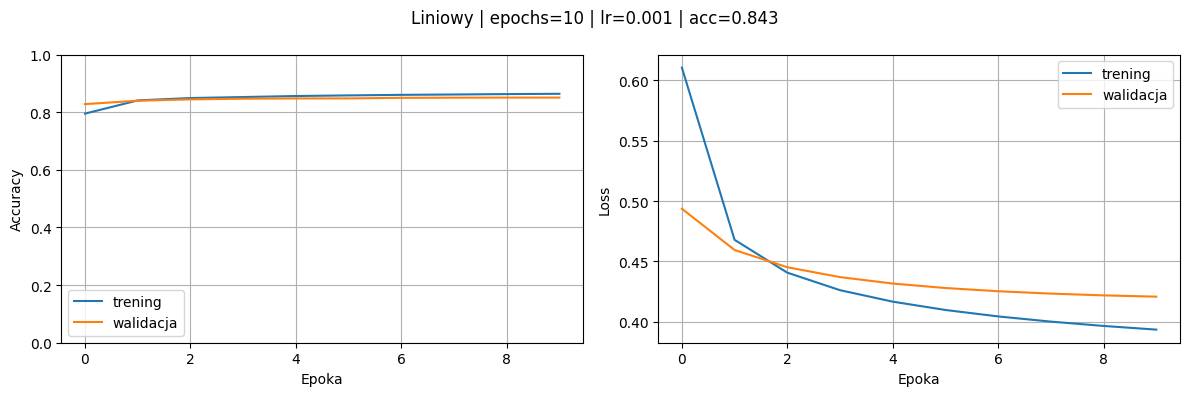

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step
Zapisano 1569 błędów -> wrong_predictions/Liniowy_epochs=10_lr=0.001/
Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 912us/step - accuracy: 0.7929 - loss: 0.6114 - val_accuracy: 0.8280 - val_loss: 0.4931
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 860us/step - accuracy: 0.8404 - loss: 0.4676 - val_accuracy: 0.8397 - val_loss: 0.4591
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - accuracy: 0.8494 - loss: 0.4403 - val_accuracy: 0.8447 - val_loss: 0.4449
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 935us/step - accuracy: 0.8533 - loss: 0.4258 - val_accuracy: 0.8475 - val_loss: 0.4367
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8563 - loss: 0.4164 - val_accuracy: 0.8488 - val_loss: 0.4314
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step - accuracy: 0.8586 - loss: 0.4095 - val_accuracy: 0.8500 - val_loss: 0.4276
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - accuracy: 0.8600 - loss: 0.4042 - val_a

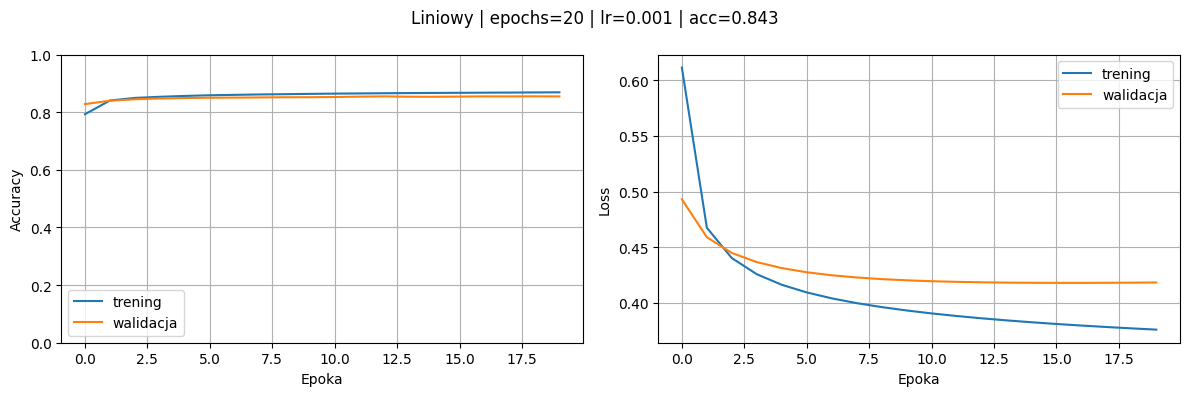

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step
Zapisano 1572 błędów -> wrong_predictions/Liniowy_epochs=20_lr=0.001/
Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7905 - loss: 0.6178 - val_accuracy: 0.8298 - val_loss: 0.4935
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8405 - loss: 0.4687 - val_accuracy: 0.8408 - val_loss: 0.4588
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 850us/step - accuracy: 0.8494 - loss: 0.4408 - val_accuracy: 0.8457 - val_loss: 0.4447
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 862us/step - accuracy: 0.8530 - loss: 0.4261 - val_accuracy: 0.8473 - val_loss: 0.4367
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 920us/step - accuracy: 0.8564 - loss: 0.4165 - val_accuracy: 0.8488 - val_loss: 0.4315
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 882us/step - accuracy: 0.8588 - loss: 0.4095 - val_accuracy: 0.8492 - val_loss: 0.4278
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 903us/step - accuracy: 0.8603 - loss: 0.4042 - val_acc

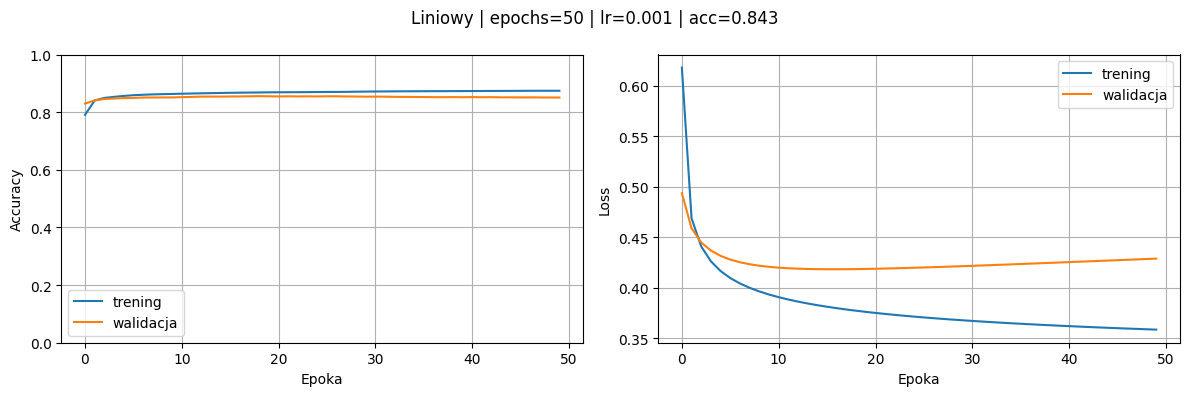

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step
Zapisano 1572 błędów -> wrong_predictions/Liniowy_epochs=50_lr=0.001/


In [ ]:
# Model liniowy - wpływ liczby epok
for i, epochs in enumerate([10, 20, 50]):
    run_experiment(build_linear_model,
                   "Liniowy",
                   lr=0.001,
                   epochs=epochs,
                   results=all_results,
                   show_summary=(i == 0))

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_37 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 969us/step - accuracy: 0.8023 - loss: 0.6210 - val_accuracy: 0.8460 - val_loss: 0.4854
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.8247 - loss: 0.5748 - val_accuracy: 0.8477 - val_loss: 0.4919
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 880us/step - accuracy: 0.8289 - loss: 0.5664 - val_accuracy: 0.8442 - val_loss: 0.5076
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 871us/step - accuracy: 0.8330 - loss: 0.5592 - val_accuracy: 0.8437 - val_loss: 0.5218
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - accuracy: 0.8349 - loss: 0.5541 - val_accuracy: 0.8413 - val_loss: 0.5352
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - accuracy: 0.8361 - loss: 0.5511 - val_accuracy: 0.8407 - val_loss: 0.5501
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - accuracy: 0.8369 - loss: 0.5496 - val_accuracy: 0.8400 - val_loss: 0.5592
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - accuracy: 0.8382 -

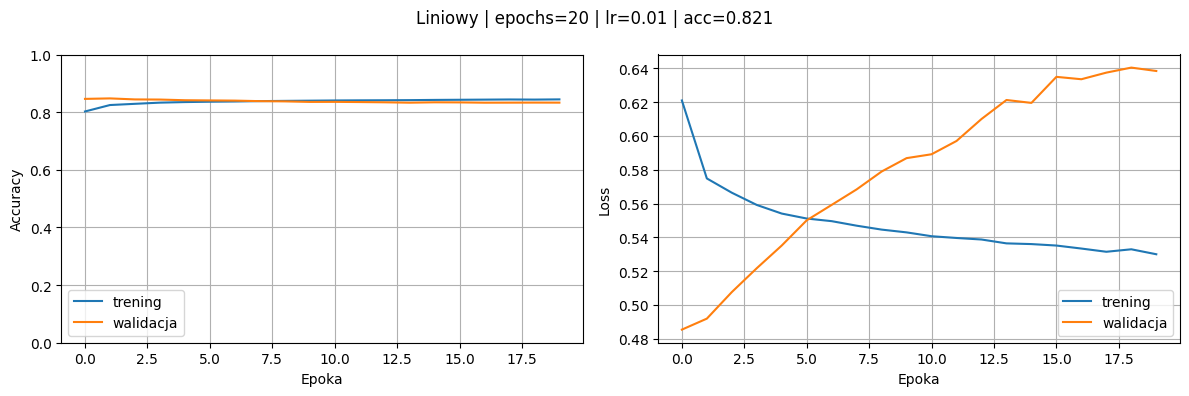

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/step
Zapisano 1788 błędów -> wrong_predictions/Liniowy_epochs=20_lr=0.01/


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_38 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7936 - loss: 0.6101 - val_accuracy: 0.8295 - val_loss: 0.4940
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step - accuracy: 0.8400 - loss: 0.4677 - val_accuracy: 0.8407 - val_loss: 0.4602
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 874us/step - accuracy: 0.8489 - loss: 0.4403 - val_accuracy: 0.8423 - val_loss: 0.4461
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step - accuracy: 0.8528 - loss: 0.4258 - val_accuracy: 0.8455 - val_loss: 0.4379
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - accuracy: 0.8554 - loss: 0.4163 - val_accuracy: 0.8457 - val_loss: 0.4325
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 854us/step - accuracy: 0.8582 - loss: 0.4094 - val_accuracy: 0.8472 - val_loss: 0.4287
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - accuracy: 0.8600 - loss: 0.4041 - val_accuracy: 0.8490 - val_loss: 0.4259
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 0.8614 - l

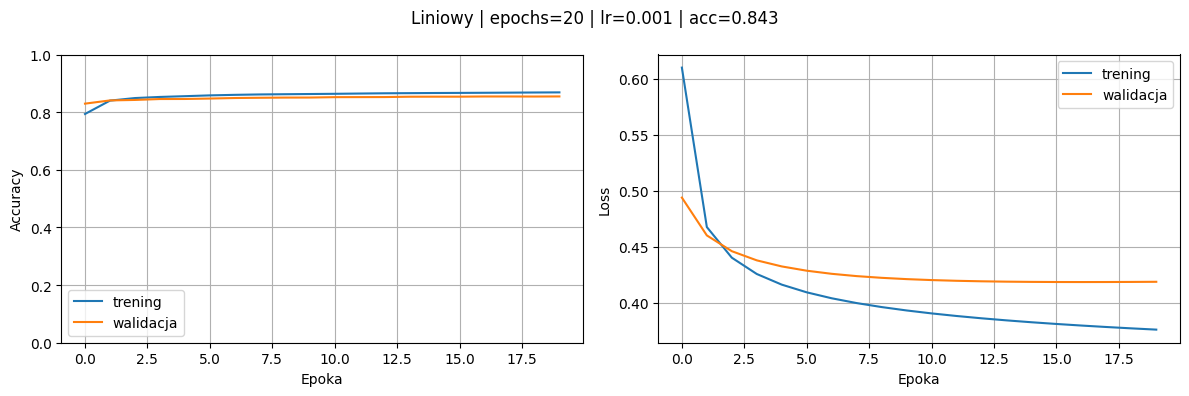

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step
Zapisano 1570 błędów -> wrong_predictions/Liniowy_epochs=20_lr=0.001/


Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_39 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6496 - loss: 1.0991 - val_accuracy: 0.7590 - val_loss: 0.7367
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 807us/step - accuracy: 0.7746 - loss: 0.6833 - val_accuracy: 0.7887 - val_loss: 0.6153
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 849us/step - accuracy: 0.8015 - loss: 0.5996 - val_accuracy: 0.8058 - val_loss: 0.5621
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - accuracy: 0.8158 - loss: 0.5562 - val_accuracy: 0.8178 - val_loss: 0.5312
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - accuracy: 0.8236 - loss: 0.5289 - val_accuracy: 0.8230 - val_loss: 0.5106
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 854us/step - accuracy: 0.8299 - loss: 0.5099 - val_accuracy: 0.8283 - val_loss: 0.4957
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - accuracy: 0.8349 - loss: 0.4957 - val_accuracy: 0.8318 - val_loss: 0.4843
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - accuracy: 0.8380 - l

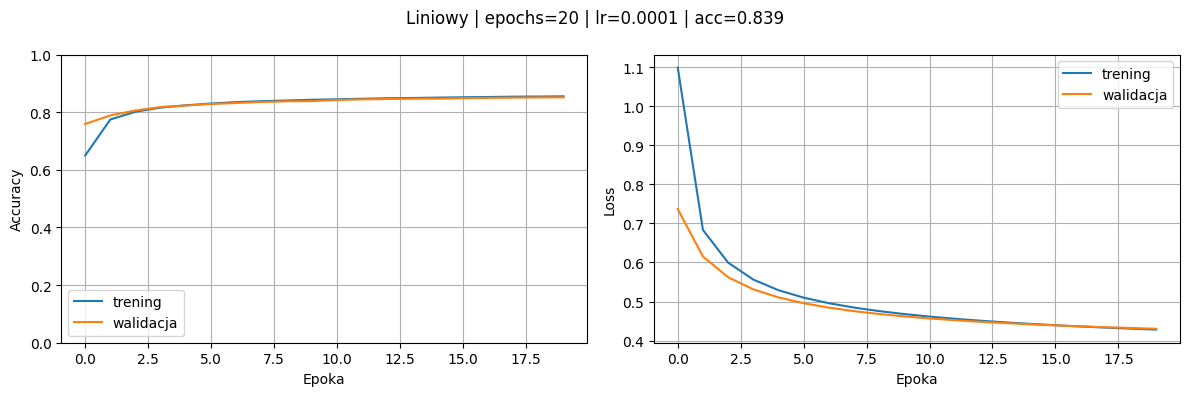

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step
Zapisano 1613 błędów -> wrong_predictions/Liniowy_epochs=20_lr=0.0001/


In [240]:
# Model liniowy — wpływ learning rate
for lr in [0.01, 0.001, 0.0001]:
    run_experiment(build_linear_model, "Liniowy", lr=lr, epochs=20, results=all_results)

## Eksperyment z siecią nieliniową (porównanie)

Następnym etapem ewaluacji zbudowanych liniowych sieci neuronowych jest porównanie ich do przykładowej sieci nieliniowej z dwiema warstwami ukrytymi, aktywowanymi za pomoca funkcji `relu` w ramach wprowadzenia nieliniowości. 

In [ ]:
# Model nieliniowy z dwiema ukrytymi warstwami ReLU - punkt odniesienia
# Dwie warstwy Dense(128) i Dense(64) z aktywacją ReLU
# wprowadzają nieliniowość, której model liniowy nie posiada
def build_dnn_model(lr):
    model = keras.Sequential([
        keras.Input(shape=(28,28)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_40 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8208 - loss: 0.5017 - val_accuracy: 0.8492 - val_loss: 0.3986
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8637 - loss: 0.3725 - val_accuracy: 0.8603 - val_loss: 0.3720
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8759 - loss: 0.3353 - val_accuracy: 0.8635 - val_loss: 0.3706
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8855 - loss: 0.3099 - val_accuracy: 0.8685 - val_loss: 0.3523
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8910 - loss: 0.2911 - val_accuracy: 0.8688 - val_loss: 0.3631
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8969 - loss: 0.2749 - val_accuracy: 0.8732 - val_loss: 0.3558
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9024 - loss: 0.2618 - val_accuracy: 0.8775 - val_loss: 0.3534
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9054 - loss: 0.2506 - 

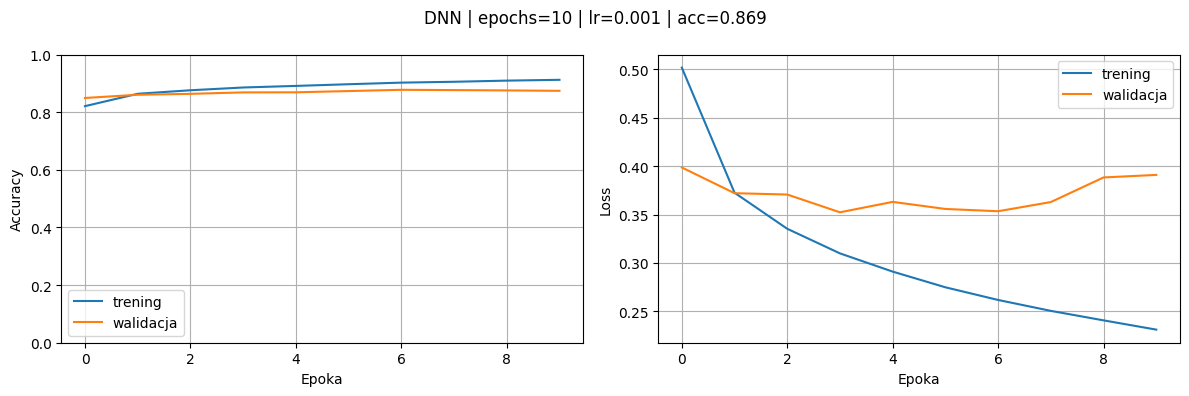

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step
Zapisano 1307 błędów -> wrong_predictions/DNN_epochs=10_lr=0.001/
Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8201 - loss: 0.5055 - val_accuracy: 0.8543 - val_loss: 0.3859
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8635 - loss: 0.3728 - val_accuracy: 0.8640 - val_loss: 0.3647
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8765 - loss: 0.3346 - val_accuracy: 0.8667 - val_loss: 0.3691
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8865 - loss: 0.3090 - val_accuracy: 0.8715 - val_loss: 0.3473
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8928 - loss: 0.2899 - val_accuracy: 0.8723 - val_loss: 0.3517
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8979 - loss: 0.2754 - val_accuracy: 0.8712 - val_loss: 0.3536
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9034 - loss: 0.2604 - val_accuracy: 0.8692 

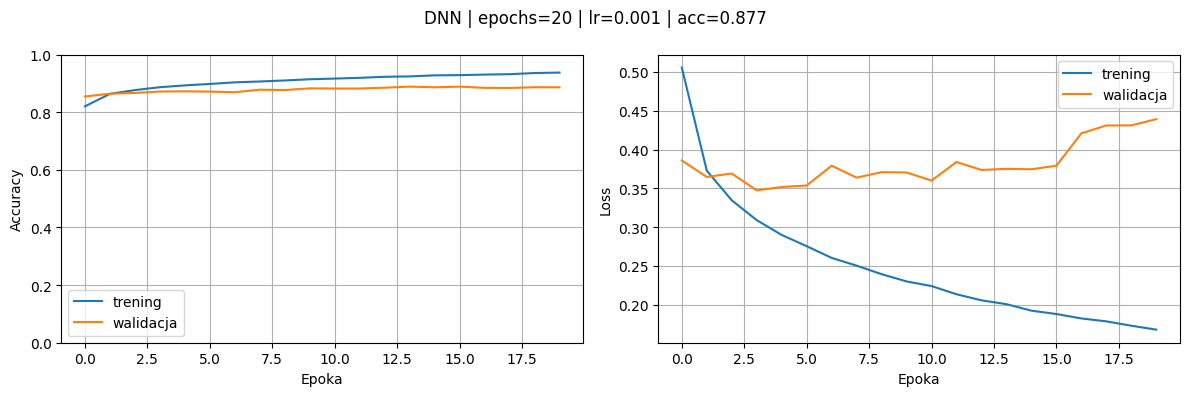

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step
Zapisano 1234 błędów -> wrong_predictions/DNN_epochs=20_lr=0.001/
Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8213 - loss: 0.5007 - val_accuracy: 0.8510 - val_loss: 0.3972
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8647 - loss: 0.3724 - val_accuracy: 0.8618 - val_loss: 0.3687
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8784 - loss: 0.3337 - val_accuracy: 0.8642 - val_loss: 0.3656
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8868 - loss: 0.3084 - val_accuracy: 0.8698 - val_loss: 0.3553
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8921 - loss: 0.2885 - val_accuracy: 0.8733 - val_loss: 0.3601
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8977 - loss: 0.2741 - val_accuracy: 0.8752 - val_loss: 0.3521
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9024 - loss: 0.2600 - val_accuracy: 0.8747 

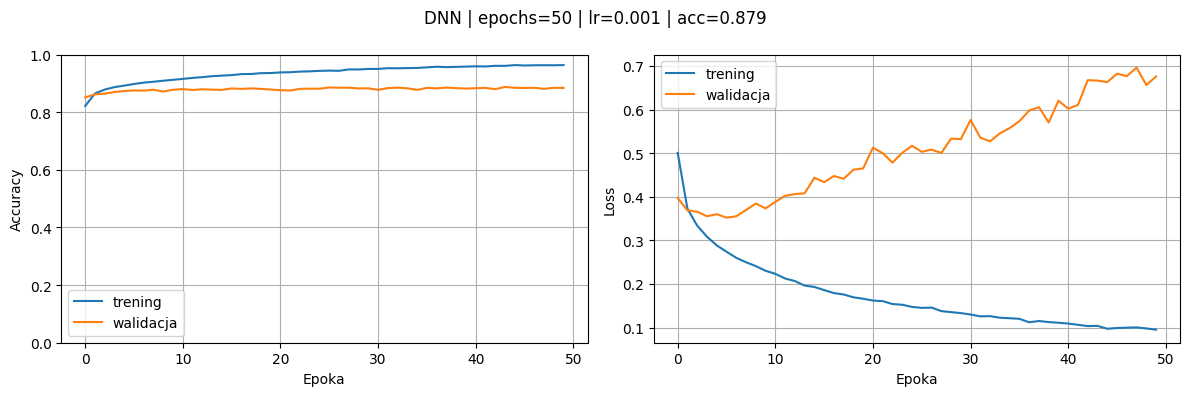

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step
Zapisano 1208 błędów -> wrong_predictions/DNN_epochs=50_lr=0.001/


In [242]:
# DNN — wpływ liczby epok  
for i, epochs in enumerate([10, 20, 50]):
    run_experiment(build_dnn_model,
                   "DNN",
                   lr=0.001,
                   epochs=epochs,
                   results=all_results,
                   show_summary=(i == 0))

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_43 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8078 - loss: 0.5402 - val_accuracy: 0.8245 - val_loss: 0.5263
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8451 - loss: 0.4367 - val_accuracy: 0.8452 - val_loss: 0.4515
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8512 - loss: 0.4243 - val_accuracy: 0.8455 - val_loss: 0.4449
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8555 - loss: 0.4068 - val_accuracy: 0.8563 - val_loss: 0.4042
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8616 - loss: 0.3934 - val_accuracy: 0.8530 - val_loss: 0.4658
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8643 - loss: 0.3858 - val_accuracy: 0.8567 - val_loss: 0.4321
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8651 - loss: 0.3824 - val_accuracy: 0.8543 - val_loss: 0.4357
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8673 - loss: 0.3781 - 

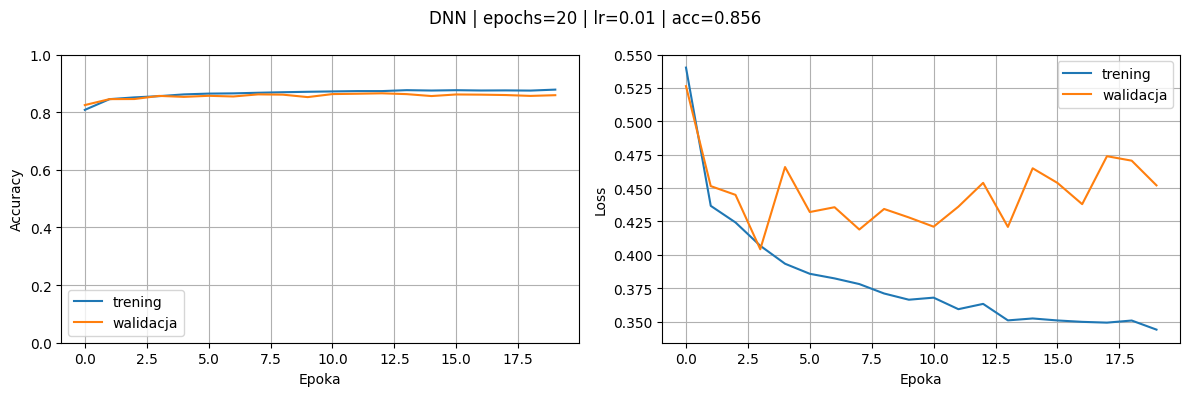

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step
Zapisano 1440 błędów -> wrong_predictions/DNN_epochs=20_lr=0.01/


Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_44 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8199 - loss: 0.5062 - val_accuracy: 0.8515 - val_loss: 0.4055
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8634 - loss: 0.3750 - val_accuracy: 0.8610 - val_loss: 0.3736
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8755 - loss: 0.3381 - val_accuracy: 0.8625 - val_loss: 0.3674
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8831 - loss: 0.3145 - val_accuracy: 0.8670 - val_loss: 0.3636
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8909 - loss: 0.2945 - val_accuracy: 0.8708 - val_loss: 0.3614
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8967 - loss: 0.2790 - val_accuracy: 0.8768 - val_loss: 0.3494
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9002 - loss: 0.2677 - val_accuracy: 0.8827 - val_loss: 0.3462
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9039 - loss: 0.2532 - 

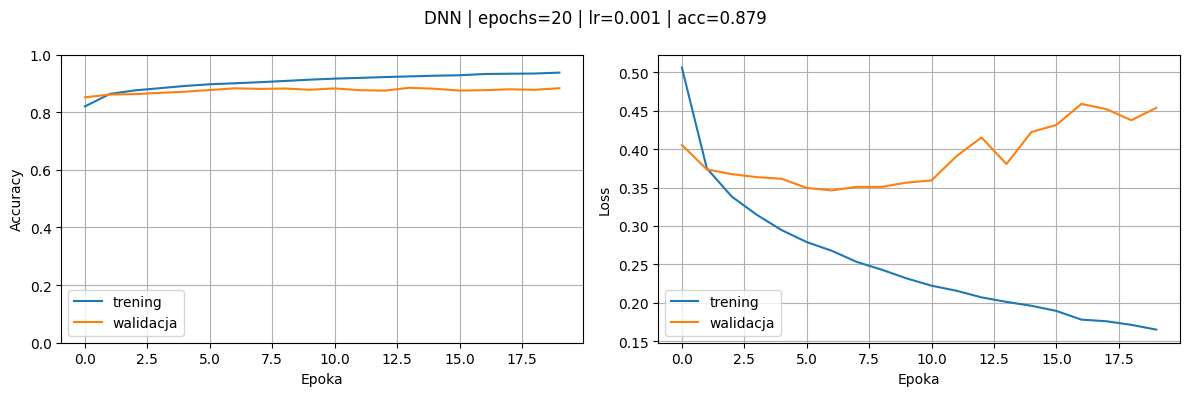

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step
Zapisano 1208 błędów -> wrong_predictions/DNN_epochs=20_lr=0.001/


Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_45 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7720 - loss: 0.7158 - val_accuracy: 0.8253 - val_loss: 0.4979
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8411 - loss: 0.4592 - val_accuracy: 0.8415 - val_loss: 0.4385
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8554 - loss: 0.4161 - val_accuracy: 0.8515 - val_loss: 0.4123
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8640 - loss: 0.3908 - val_accuracy: 0.8583 - val_loss: 0.3963
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8695 - loss: 0.3724 - val_accuracy: 0.8637 - val_loss: 0.3838
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8744 - loss: 0.3576 - val_accuracy: 0.8665 - val_loss: 0.3735
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8783 - loss: 0.3451 - val_accuracy: 0.8702 - val_loss: 0.3652
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8816 - loss: 0.3341 - 

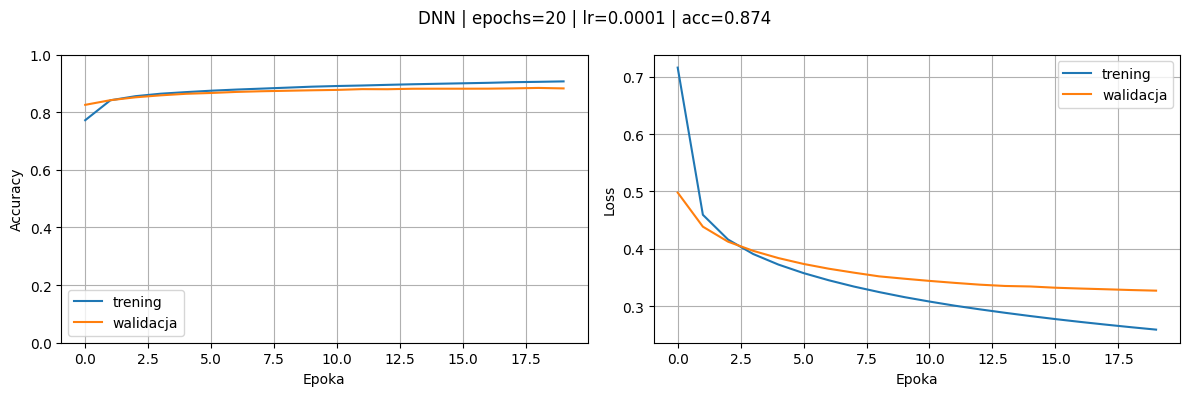

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step
Zapisano 1262 błędów -> wrong_predictions/DNN_epochs=20_lr=0.0001/


In [243]:
# DNN — wpływ learning rate
for lr in [0.01, 0.001, 0.0001]:
    run_experiment(build_dnn_model, "DNN", lr=lr, epochs=20, results=all_results)

## Analiza wyników klasyfikacji

Rezultaty zebrane z przeprowadzonych eksperymentów zostały skondensowane do jednej tabeli, gdzie modele posortowano ze względu na wartość wskaźnika accuracy (prezycja). Ponad to, duplikaty zostały usunięte.

In [244]:
summary = pd.DataFrame(all_results)
summary = summary.drop_duplicates(subset=["Model", "Epochs", "Learning rate"])
summary = summary.sort_values("Accuracy", ascending=False).reset_index(drop=True)
summary

,Model,Epochs,Learning rate,Accuracy
0,DNN,50,0.0010,0.8792
1,DNN,20,0.0010,0.8766
2,DNN,20,0.0001,0.8738
3,DNN,10,0.0010,0.8693
4,DNN,20,0.0100,0.8560
5,Liniowy,10,0.0010,0.8431
6,Liniowy,20,0.0010,0.8428
7,Liniowy,50,0.0010,0.8428
8,Liniowy,20,0.0001,0.8387
9,Liniowy,20,0.0100,0.8212


Pierwszy wykres zbiory (pokazany poniżej), przestawia wykres wartości `accuracy` w funkcji `learning rate` dla obu modeli - liniowego oraz nieliniowego. Jak można zauważyć zarówno dla modelu liniowego jak i nieliniowego ukazuje się wyraźna górka dla wartości `learning rate` równej `0.001`, co oznacza że wartość wyższa niż ta wskazuje problem z tzw. overfittingiem, czyli przetrenowaniem sieci, natomiast wartość mniejsza jest powoduje mniej efektywne ucznie. 

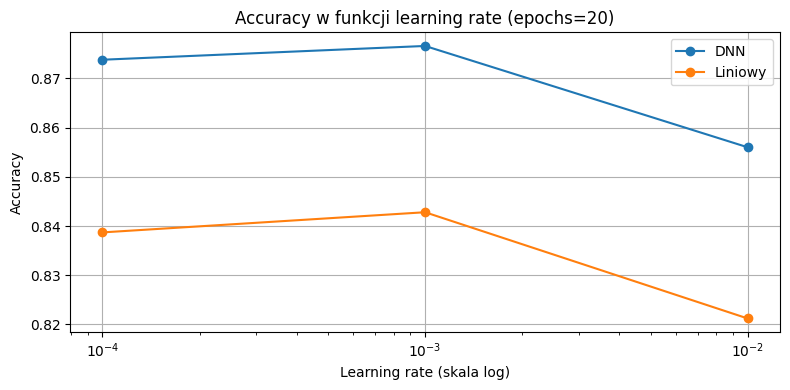

In [245]:
# Zbiorczy wykres accuracy w funkcji learning rate dla obu modeli
# Dane: eksperymenty z epochs=20, zmienny lr
lr_results = summary[summary["Epochs"] == 20].copy()

plt.figure(figsize=(8, 4))
for model_name, group in lr_results.groupby("Model"):
    group_sorted = group.sort_values("Learning rate")
    plt.plot(group_sorted["Learning rate"], group_sorted["Accuracy"],
             marker="o", label=model_name)

plt.xscale("log")
plt.xlabel("Learning rate (skala log)")
plt.ylabel("Accuracy")
plt.title("Accuracy w funkcji learning rate (epochs=20)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Drugi wykres zbiorczy przedstawia charakterystykę accuracy w funkcji epok, czyli jak ilość epok wpływa na `accuracy` przy stałym `learning rate`. Tutaj dla modelu nieliniowego i liniowego wnioski są inne - dla modelu nieliniowego im większa ilość epok tym wskaźnic accuracy jest większy, natomaist dla sieci liniowej różnice są lewdo zauważalne.

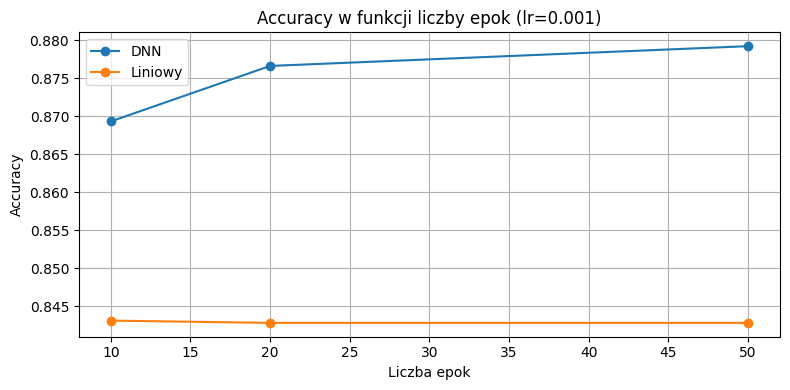

In [246]:
# Zbiorczy wykres accuracy w funkcji liczby epok dla obu modeli
# Dane: eksperymenty z lr=0.001, zmienna liczba epok
epoch_results = summary[summary["Learning rate"] == 0.001].copy()

plt.figure(figsize=(8, 4))
for model_name, group in epoch_results.groupby("Model"):
    group_sorted = group.sort_values("Epochs")
    plt.plot(group_sorted["Epochs"], group_sorted["Accuracy"],
             marker="o", label=model_name)

plt.xlabel("Liczba epok")
plt.ylabel("Accuracy")
plt.title("Accuracy w funkcji liczby epok (lr=0.001)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [247]:
# Trening finalnego modelu na podstawie najlepszych parametrów z eksperymentów
best_model = build_dnn_model(lr=0.001)
best_model.fit(
    train_images_normalized, train_labels,
    epochs=50,
    validation_split=0.1,
    verbose=1
)

# Predykcje
y_pred_proba = best_model.predict(test_images_normalized)
y_pred       = np.argmax(y_pred_proba, axis=1)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8207 - loss: 0.5104 - val_accuracy: 0.8550 - val_loss: 0.3892
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8631 - loss: 0.3764 - val_accuracy: 0.8643 - val_loss: 0.3678
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8764 - loss: 0.3381 - val_accuracy: 0.8650 - val_loss: 0.3634
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8842 - loss: 0.3140 - val_accuracy: 0.8655 - val_loss: 0.3627
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8914 - loss: 0.2941 - val_accuracy: 0.8707 - val_loss: 0.3566
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8967 - loss: 0.2789 - val_accuracy: 0.8748 - val_loss: 0.3502
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9026 - loss: 0.2628 - val_accuracy: 0.8677 - val_loss: 0.3778
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9066 - loss: 0.2510 - 

W tym miejscu w ramach dokładniejszej analizy otrzymanych wyników został utworzony tzw. confusion matrix, czli macierz pomyłek. Po przekątnej widać ile z próbek zostało poprawnie zaklasyfikowanych a na pozostałych polach są widoczne błędne klasyfikacje. Na podstawie tejże macierzy pomyłek widać, że największe problemy w klasyfikacji sprawily głównie trzy klasy: `Shirt`, `Pullover` oraz `Coat`.

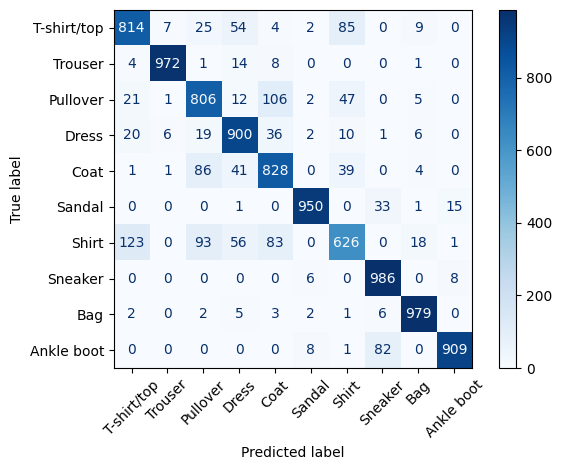

In [248]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    test_labels, y_pred,
    display_labels=class_names,
    xticks_rotation=45,
    cmap="Blues"
)
plt.tight_layout()
plt.show()

Poniżej w ramach daleszej analizy zostały pokazane wartości parametrów precision, recall i F1 dla każdej z klas. Jak widać, wartości wszystkich klas oprócz `Shirt` są na ogół dosyć wysokie.

Poszczególne wartości w praktyce oznaczają:
 - Precision - niska wartość oznacza że model nadużywa tej klasy, czyli oznacza ją tam gdzie nie powinien
 - Recall - niska wartość oznacza że model "przegapia" daną klasę, czyli za rzadko ją przewiduje
 - F1 - jest to wartość, która przedstawia średnią harmoniczną precision i recall, czyli balansuje precision i recall

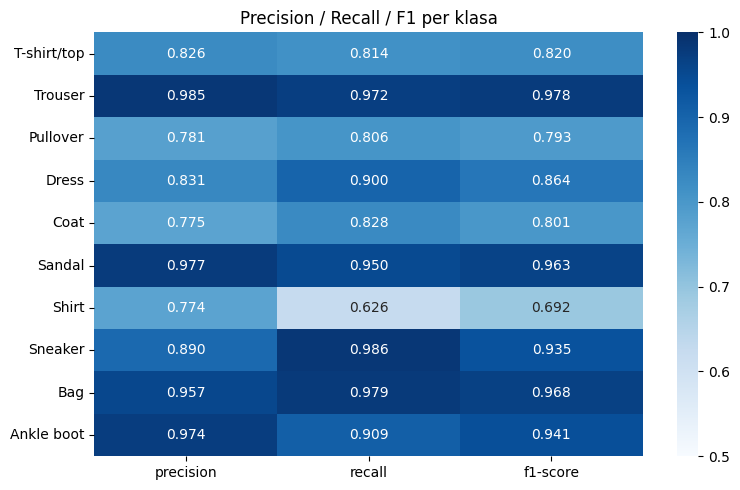

In [249]:
from sklearn.metrics import classification_report

report = classification_report(
    test_labels, y_pred,
    target_names=class_names,
    output_dict=True
)

# Wizualizacja jako heatmapa — czytelniejsza niż surowy tekst
report_df = pd.DataFrame(report).T.iloc[:-3, :3]  # tylko klasy, bez avg
report_df = report_df.astype(float).round(3)

plt.figure(figsize=(8, 5))
sns.heatmap(report_df, annot=True, fmt=".3f", cmap="Blues", vmin=0.5, vmax=1.0)
plt.title("Precision / Recall / F1 per klasa")
plt.tight_layout()
plt.show()

Dla dodatkowej wizualizacji w tym miejscu zostają przedstawione przykładowe obrazy, które zostały poddane błędnej klasyfikacji.

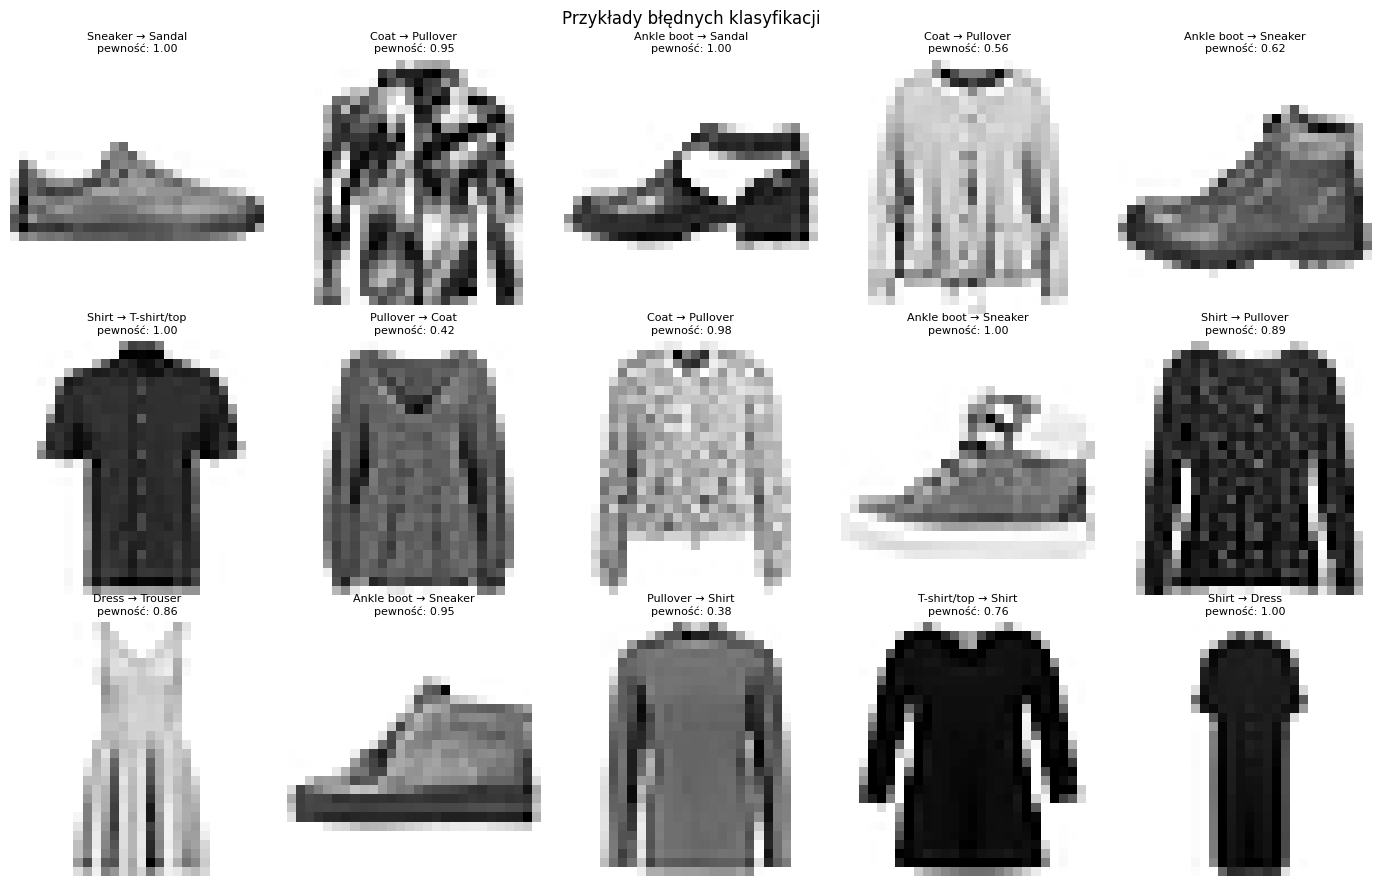

In [250]:
wrong_idx = np.where(y_pred != test_labels)[0]

fig, axes = plt.subplots(3, 5, figsize=(14, 9))
fig.suptitle("Przykłady błędnych klasyfikacji")

for ax, idx in zip(axes.flat, wrong_idx[:15]):
    ax.imshow(test_images_normalized[idx], cmap="binary")
    ax.set_title(
        f"{class_names[test_labels[idx]]} → {class_names[y_pred[idx]]}\n"
        f"pewność: {y_pred_proba[idx, y_pred[idx]]:.2f}",
        fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Ostatni wykres przedstawia pewność predykcji w formie różnicy wartości `top1` i `top2`. W praktyce oznacza to z jaką "pewnością" model zaklasyfikował daną próbkę do danej klasy. Na wykresie widać, że obie wartości są skośne lewostronnie, co oznacza że model był zarówno pewny poprawnych klasyfikacji jak i tych niepoprawnych.

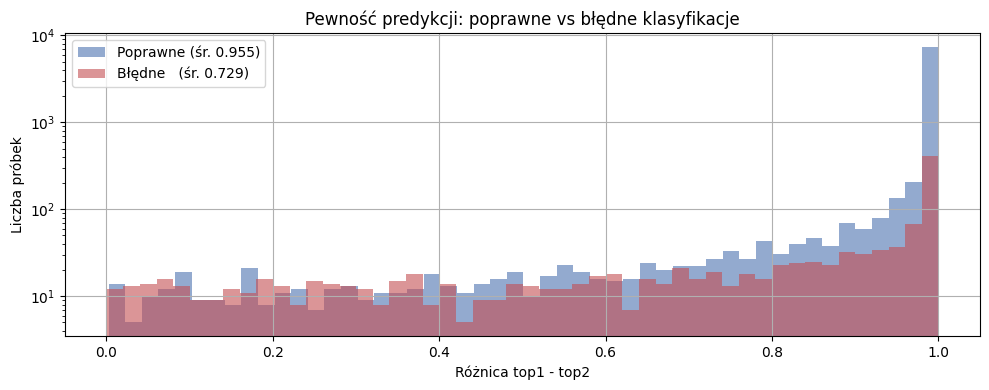

In [251]:
# Różnica między najwyższym a drugim prawdopodobieństwem — miara pewności modelu
sorted_proba = np.sort(y_pred_proba, axis=1)[:, ::-1]
margin = sorted_proba[:, 0] - sorted_proba[:, 1]
correct_mask = (y_pred == test_labels)

plt.figure(figsize=(10, 4))
plt.hist(margin[correct_mask],  bins=50, alpha=0.6, label=f"Poprawne (śr. {margin[correct_mask].mean():.3f})",  color="#4C72B0")
plt.hist(margin[~correct_mask], bins=50, alpha=0.6, label=f"Błędne   (śr. {margin[~correct_mask].mean():.3f})", color="#C44E52")
plt.yscale("log")
plt.xlabel("Różnica top1 - top2")
plt.ylabel("Liczba próbek")
plt.title("Pewność predykcji: poprawne vs błędne klasyfikacje")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Podsumowanie i wnioski

Celem projektu była klasyfikacja obrazów z datasetu Fashion MNIST z wykorzystaniem biblioteki Keras, ze szczególnym naciskiem na analizę liniowej sieci neuronowej oraz jej porównanie z głęboką siecią nieliniową (DNN).

Przeprowadzone eksperymenty wykazały, że dla obu architektur optymalną wartością współczynnika uczenia okazało się `lr`=0.001. Wartość wyższa (`lr`=0.01) prowadziła do niestabilnego treningu i objawów overfittingu widocznych na krzywych funkcji straty - `val_loss` przestawał maleć lub zaczynał rosnąć podczas gdy loss treningowy nadal się obniżał. Wartość niższa (`lr`=0.0001) skutkowała wolniejszą i mniej efektywną konwergencją, co przekładało się na niższe końcowe accuracy przy tej samej liczbie epok.

Wpływ liczby epok. Dla modelu liniowego zwiększanie liczby epok powyżej 20 przynosiło marginalne korzyści - model osiągał swój sufit możliwości stosunkowo szybko, co jest bezpośrednią konsekwencją jego architektury. Brak warstw ukrytych z nieliniową aktywacją ogranicza zdolność modelu do wychwytywania złożonych wzorców w danych, przez co dodatkowe epoki nie wnoszą istotnej poprawy. Model DNN natomiast konsekwentnie poprawiał accuracy wraz ze wzrostem liczby epok, osiągając najlepsze wyniki przy `epochs`=50.

Analiza błędów klasyfikacji. Macierz pomyłek oraz raport precision/recall/F1 ujawniły że najtrudniejszymi klasami do poprawnej klasyfikacji były `Shirt`, `Pullover` oraz `Coat`. Przyczyną jest ich wizualne podobieństwo - wszystkie trzy klasy mają zbliżony obrys sylwetki, podobną strefę kołnierza i długość rękawów, a rozdzielczość 28×28 pikseli nie dostarcza wystarczającej ilości szczegółów do pewnego rozróżnienia. Klasy takie jak `Trouser` i `Bag` były natomiast klasyfikowane niemal bezbłędnie ze względu na unikalny i charakterystyczny kształt.